# Serial Repetition Lag-Rank Analysis

> Per-presentation temporal factor scores for transitions from repeated items during correct serial run-up.

The serial repetition lag-rank analysis measures temporal organization of
transitions FROM repeated items, restricted to the first qualifying
transition during a correct serial run-up. It parallels `serialrepcrp` but
produces a scalar factor per presentation index instead of a CRP curve.
A score of 0.5 indicates chance; scores above 0.5 reflect temporal contiguity.

This notebook is parameterized for use with [papermill](https://papermill.readthedocs.io/).

| Parameter | Description |
|-----------|-------------|
| `data_path` | Path to HDF5 dataset file |
| `figure_dir` | Directory for saving figures |
| `figure_str` | Filename for saved figure (empty string to skip saving) |
| `trial_query` | Query selecting trials to analyze |
| `min_lag` | Minimum spacing between repeated presentations |
| `size` | Max study positions an item can occupy |

: Notebook parameters {#tbl-parameters}

In [1]:
#| include: false
from nbdev.showdoc import show_doc

In [2]:
#| code-summary: Imports and setup
import os
import warnings

import numpy as np
import matplotlib.pyplot as plt

from jaxcmr.analyses.serialreplagrank import (
    serialreplagrank,
    plot_serial_rep_lagrank,
    subject_serial_rep_lagrank,
)
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data

warnings.filterwarnings("ignore")


def save_figure(figure_dir, figure_str, suffix=None):
    plt.tight_layout()
    if not figure_str:
        plt.show()
        return
    os.makedirs(figure_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    figure_path = os.path.join(figure_dir, f"{figure_str}{suffix_str}.png")
    plt.savefig(figure_path, bbox_inches="tight", dpi=600)
    plt.show()

In [3]:
#| code-summary: Parameters for this analysis

data_path = "data/LohnasKahana2014.h5"
figure_dir = "results/figures"
figure_str = ""
trial_query = "data['list_type'] > 2"
min_lag = 4
size = 2

In [4]:
#| code-summary: Load data
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)

data = load_data(data_path)
trial_mask = generate_trial_mask(data, trial_query)

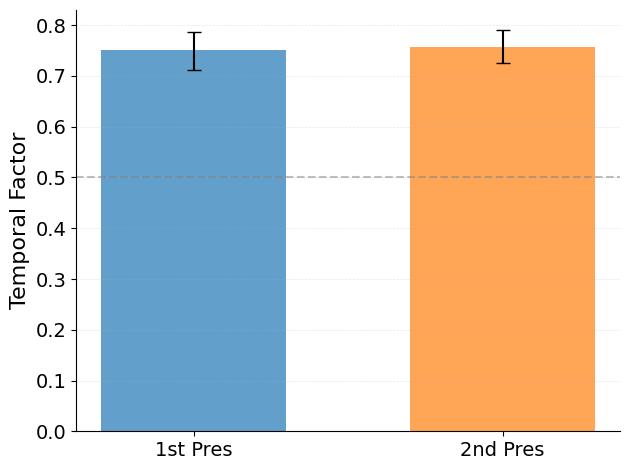

In [5]:
#| code-summary: Plot serial repetition lag-rank factors
#| label: fig-serialreplagrank
#| fig-cap: "Per-presentation temporal factor during serial run-up. Dashed line indicates chance (0.5)."
plot_serial_rep_lagrank(data, trial_mask, min_lag=min_lag, size=size, labels=["1st Pres", "2nd Pres"])
save_figure(figure_dir, figure_str)

## Summary

In [6]:
#| code-summary: Per-presentation serial temporal factors
factors = subject_serial_rep_lagrank(data, trial_mask, min_lag=min_lag, size=size)

print()
print("=" * 60)
print("Serial Per-Presentation Temporal Factor")
print("=" * 60)
print(f"N = {factors.shape[0]} subjects")
for k in range(size):
    print(f"  Presentation {k+1}: mean = {np.nanmean(factors[:, k]):.4f}")


Serial Per-Presentation Temporal Factor
N = 35 subjects
  Presentation 1: mean = 0.7521
  Presentation 2: mean = 0.7574


---

## Reference

In [7]:
#| echo: false
show_doc(serialreplagrank)

---

### serialreplagrank

>      serialreplagrank (dataset:jaxcmr.typing.RecallDataset, min_lag:int=4,
>                        size:int=2)

*Compute serial per-trial per-presentation lag-rank factors.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| dataset | RecallDataset |  | Dataset with ``recalls`` and ``pres_itemnos``. |
| min_lag | int | 4 | Minimum spacing between repeated presentations. |
| size | int | 2 | Maximum presentations per item. |
| **Returns** | **Float[Array, 'trials size']** |  | **Per-trial temporal factor for each presentation index.** |

In [8]:
#| echo: false
show_doc(subject_serial_rep_lagrank)

---

### subject_serial_rep_lagrank

>      subject_serial_rep_lagrank (dataset:jaxcmr.typing.RecallDataset,
>                                  trial_mask:jaxtyping.Bool[Array,'trial_count'
>                                  ], min_lag:int=4, size:int=2)

*Compute per-subject per-presentation serial lag-rank factor.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| dataset | RecallDataset |  | Recall dataset. |
| trial_mask | Bool[Array, 'trial_count'] |  | Boolean mask selecting trials. |
| min_lag | int | 4 | Minimum spacing between repeated presentations. |
| size | int | 2 | Maximum presentations per item. |
| **Returns** | **ndarray** |  | **Shape ``(n_subjects, size)``.** |

In [9]:
#| echo: false
show_doc(plot_serial_rep_lagrank)

---

### plot_serial_rep_lagrank

>      plot_serial_rep_lagrank (datasets:Union[Sequence[jaxcmr.typing.RecallData
>                               set],jaxcmr.typing.RecallDataset], trial_masks:U
>                               nion[Sequence[jaxtyping.Bool[Array,'trial_count'
>                               ]],jaxtyping.Bool[Array,'trial_count']],
>                               min_lag:int=4, size:int=2,
>                               color_cycle:Optional[list[str]]=None,
>                               labels:Optional[Sequence[str]]=None,
>                               contrast_name:Optional[str]=None,
>                               axis:Optional[matplotlib.axes._axes.Axes]=None,
>                               confidence_level:float=0.95)

*Plot serial per-presentation lag-rank factors as a grouped bar chart.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| datasets | Union |  | One or more datasets to plot. |
| trial_masks | Union |  | Boolean mask(s) selecting trials. |
| min_lag | int | 4 | Minimum spacing between repeated presentations. |
| size | int | 2 | Maximum presentations per item. |
| color_cycle | Optional | None | Colors for each bar. |
| labels | Optional | None | Labels for each presentation bar. |
| contrast_name | Optional | None | Legend title. |
| axis | Optional | None | Existing Axes to plot on. |
| confidence_level | float | 0.95 | Confidence level for error bounds. |
| **Returns** | **Axes** |  | **Matplotlib Axes with the grouped bar chart.** |

In [10]:
# Both presentations should show temporal contiguity for serial run-ups
assert np.nanmean(factors[:, 0]) > 0.5, "First presentation factor should exceed chance"
assert np.nanmean(factors[:, 1]) > 0.5, "Second presentation factor should exceed chance"